In [1]:
df=spark.sql("""

SELECT *
FROM Anomaly_output

""").toPandas()

print(df.shape)

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 3, Finished, Available, Finished, False)

(21792, 59)


In [2]:
anomalies=df[
df[
"anomaly_flag"
]==1
].copy()

print(
"Detected anomalies:"
)

print(
anomalies.shape
)

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 4, Finished, Available, Finished, False)

Detected anomalies:
(1090, 59)


In [3]:
import pandas as pd
features=[

"components_nh3",
"components_co",

"components_no",
"components_no2",

"components_so2",

"components_pm10",
"components_pm2_5",

"PM10_PM25_ratio"

]

for c in features:

    anomalies[c]=pd.to_numeric(
        anomalies[c],
        errors="coerce"
    )

anomalies[
features
]=anomalies[
features
].fillna(0)

print(
"Data cleaned"
)

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 5, Finished, Available, Finished, False)

Data cleaned


In [4]:
def classify_source(row):

    # Crop burning

    if (

        row["components_nh3"]>30

        and

        row["components_co"]>800

    ):

        return "Crop Burning"


    # Vehicular

    elif (

        row["components_no"]>40

        and

        row["components_no2"]>40

    ):

        return "Vehicular"


    # Industrial

    elif (

        row["components_so2"]>30

    ):

        return "Industrial"


    # Dust Storm

    elif (

        row["PM10_PM25_ratio"]>2

    ):

        return "Dust Storm"


    return "Mixed Sources"

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 6, Finished, Available, Finished, False)

In [5]:
anomalies[
"predicted_source"
]=anomalies.apply(

classify_source,

axis=1

)

anomalies[
"predicted_source"
].value_counts()

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 7, Finished, Available, Finished, False)

predicted_source
Crop Burning     693
Mixed Sources    201
Industrial        88
Vehicular         63
Dust Storm        45
Name: count, dtype: int64

In [6]:
import numpy as np

conditions=[

anomalies[
"anomaly_score"
]<0.50,

anomalies[
"anomaly_score"
]<0.75

]

choices=[

0.65,
0.85

]

anomalies[
"confidence"
]=np.select(

conditions,
choices,

default=.95

)

anomalies[
[
"predicted_source",
"confidence"
]
].head()

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 8, Finished, Available, Finished, False)

,predicted_source,confidence
496,Crop Burning,0.65
497,Crop Burning,0.65
498,Crop Burning,0.65
499,Crop Burning,0.65
500,Crop Burning,0.65


StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 9, Finished, Available, Finished, False)

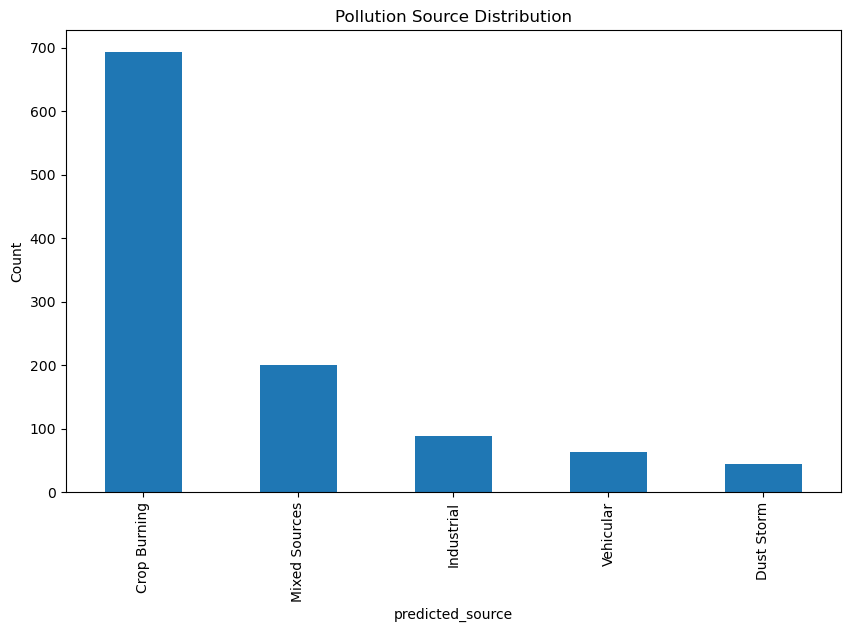

In [7]:
import matplotlib.pyplot as plt

source_counts=anomalies["predicted_source"].value_counts()

plt.figure(
figsize=(10,6)
)

source_counts.plot(
kind="bar"
)

plt.title(
"Pollution Source Distribution"
)

plt.ylabel(
"Count"
)

plt.show()

In [10]:
spark.createDataFrame(
anomalies
).write.mode(
"overwrite"
).format(
"delta"
).saveAsTable(
"Classification_output"
)

print(
"Classification output saved"
)

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 13, Finished, Available, Finished, False)

Classification output saved


In [11]:
display(

spark.sql("""

SELECT

parsed_datetime,
city,
predicted_source,
confidence

FROM Classification_output

LIMIT 20

""")

)

StatementMeta(, 75972389-2204-4482-9bc2-277b7e6b8f6d, 14, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 23eb854d-66cb-4e7e-ae5d-5a1b38741117)